# Lab: Envelope Modulation of a Random Process with Prescribed $R_x(\tau)$

## Objective

Study how a zero-mean wide-sense stationary random process with prescribed autocorrelation function $R_x(\tau)$ is transformed through a carrier-modulation chain:

1. specification and validation of the target second-order model,
2. synthesis of one realization of the input process,
3. multiplicative carrier modulation,
4. envelope detection by rectification and low-pass filtering,
5. comparison of the recovered envelope signal with the original input realization and its magnitude structure.

At each stage, estimate the autocorrelation function (ACF) and power spectral density (PSD), then compare empirical results against the corresponding theoretical predictions.

## Lab Flow and Stage Map

Proposed stage sequence:

1. Parameter selection.
2. Stage 0: target-process model design and admissibility check.
3. Stage 1: realization synthesis and validation of $x[n]$.
4. Stage 2: multiplicative carrier modulation.
5. Stage 3: envelope detection and baseband recovery.
6. Stage 4: comparison, metrics, and interpretation.

Each stage should produce a small, explicit set of plots and checks before moving to the next one. The proposed chain is

$$
x[n] \;\longrightarrow\; y[n] = x[n]\cos(2\pi f_c nT_s) \;\longrightarrow\; |y[n]| \;\longrightarrow\; \hat{x}_{\mathrm{env}}[n].
$$

Because there is no carrier bias term, the final stage should be interpreted as envelope recovery of magnitude and low-frequency structure, not exact signed-waveform demodulation.

## Input Process Model

Let the target autocorrelation be defined as a symmetric Gaussian mixture:

$$
R_x(\tau) = A_0 e^{-\tau^2/(2\sigma_0^2)} + \sum_{m=1}^{M} A_m \left[e^{-(\tau-\tau_m)^2/(2\sigma_m^2)} + e^{-(\tau+\tau_m)^2/(2\sigma_m^2)}\right].
$$

Interpretation of the parameters:

- $A_0$ controls the central correlation peak.
- $A_m$ controls the strength of each shifted Gaussian component.
- $\tau_m$ controls the location of each correlation lobe.
- $\sigma_m$ controls the width of each lobe and therefore the corresponding spectral spread.

The process used in the lab is assumed zero mean, real valued, and WSS. The corresponding PSD is obtained from the Fourier transform of $R_x(\tau)$:

$$
S_x(\omega) = \sqrt{2\pi}\,A_0\sigma_0 e^{-\sigma_0^2\omega^2/2}
+ 2\sqrt{2\pi}\sum_{m=1}^{M} A_m\sigma_m e^{-\sigma_m^2\omega^2/2}\cos(\omega\tau_m).
$$

Admissibility condition:

$$
R_x \text{ is a valid ACF } \Longleftrightarrow S_x(\omega) \ge 0 \quad \forall\,\omega.
$$

This condition must be checked before synthesis. The Gaussian-mixture expression is not automatically admissible for arbitrary shifts and weights.

## Theoretical Background

The modulated waveform is defined by

$$
y(t) = x(t)\,\mathrm{Re}\{e^{j\omega_c t}\} = x(t)\cos(\omega_c t).
$$

Its discrete-time counterpart is

$$
y[n] = x[n]\cos(2\pi f_c nT_s), \qquad T_s = \frac{1}{f_s}, \quad \omega_c = 2\pi f_c.
$$

Because the carrier is purely multiplicative and no DC bias is added, this is not conventional AM with guaranteed positive envelope. The rectifier-plus-low-pass stage is therefore a nonlinear transformation that mainly preserves magnitude information and low-frequency structure.

### Analytical derivation of $R_y$

Assume that $x(t)$ is real and WSS with autocorrelation

$$
R_x(\tau) = \mathbb{E}\{x(t)x(t+\tau)\}.
$$

Starting from the modulation law,

$$
\mathbb{E}\{y(t)y(t+\tau)\}
= \mathbb{E}\{x(t)x(t+\tau)\}\cos(\omega_c t)\cos(\omega_c(t+\tau)).
$$

Since $x(t)$ is WSS,

$$
\mathbb{E}\{x(t)x(t+\tau)\} = R_x(\tau).
$$

Using

$$
\cos a\cos b = \frac{1}{2}\left[\cos(a-b)+\cos(a+b)\right],
$$

the exact second-order correlation of the modulated process becomes

$$
R_y(t,\tau) = \frac{R_x(\tau)}{2}\left[\cos(\omega_c\tau)+\cos(2\omega_c t + \omega_c\tau)\right].
$$

Therefore $y(t)$ is generally not WSS; it is cyclostationary because the correlation depends on the absolute time $t$.

If the lab uses the cycle-averaged correlation over one carrier period $T_c = 2\pi/\omega_c$, define

$$
\overline{R}_y(\tau) = \frac{1}{T_c}\int_0^{T_c} R_y(t,\tau)\,dt.
$$

The oscillatory term in $2\omega_c t + \omega_c\tau$ averages to zero, so

$$
\overline{R}_y(\tau) = \frac{1}{2}R_x(\tau)\cos(\omega_c\tau).
$$

### Analytical validation that $\overline{R}_y$ is a valid ACF

Write the cosine factor as complex exponentials:

$$
\overline{R}_y(\tau)
= \frac{1}{4}R_x(\tau)e^{j\omega_c\tau} + \frac{1}{4}R_x(\tau)e^{-j\omega_c\tau}.
$$

This yields the cycle-averaged PSD

$$
\overline{S}_y(\omega) = \frac{1}{4}S_x(\omega-\omega_c) + \frac{1}{4}S_x(\omega+\omega_c).
$$

If $R_x$ is valid, then $S_x(\omega) \ge 0$ for all $\omega$, hence $\overline{S}_y(\omega) \ge 0$ for all $\omega$. By Wiener-Khinchin, $\overline{R}_y$ is therefore a valid ACF.

The exact quantity $R_y(t,\tau)$ is a cyclostationary correlation function, while $\overline{R}_y(\tau)$ is the stationary object used for ACF and PSD comparisons in the lab.

## 1. Parameter Selection

Choose the experiment parameters before any synthesis:

### Process-Model Parameters

- Select $M$, $A_0$, $A_m$, $\tau_m$, and $\sigma_m$.
- Verify that $R_x(0) > 0$ and that the resulting $S_x(\omega)$ is nonnegative.
- Identify an effective message bandwidth $B_x$ from the support or concentration of $S_x(f)$.

### Carrier Parameters

- Choose carrier frequency $f_c = k B_x$ with a clear guard factor, for example $k \in [20,30]$.
- Keep $f_c$ high enough that the shifted spectra do not overlap the baseband support of interest.

### Sampling and Observation Parameters

- Choose sampling frequency $f_s$ comfortably above $2f_c$, with margin for spectral visualization and filtering.
- Choose observation time $T$ long enough that the frequency resolution $\Delta f = 1/T$ resolves the narrowest relevant spectral features.
- Choose the lag window large enough to capture the dominant support of $R_x(\tau)$, including shifted lobes around $\pm\tau_m$.

### Demodulator and PSD-Estimation Parameters

- Choose demodulator cutoff $f_{\mathrm{demod}}$ to pass the effective baseband support of the envelope content while attenuating carrier-related ripple.
- Choose Welch parameters: segment length, overlap, and window.
- State the expected PSD frequency resolution implied by those choices.

This section should end with one compact table summarizing all selected values and the rationale for each.

In [14]:
# Stage 0/1 setup: NumPy FFT synthesis is sufficient here, so PyTorch is not used.
try:
    import numpy as np
    import matplotlib.pyplot as plt
except ImportError as exc:
    raise ImportError(
        "This notebook requires numpy and matplotlib in the active Jupyter kernel."
    ) from exc

plt.style.use("default")
rng = np.random.default_rng(7)

params = {
    "fs": 2048.0,
    "N": 65536,
    "max_lag_seconds": 0.25,
    "welch_nperseg": 4096,
    "welch_noverlap": 2048,
    "energy_fraction": 0.995,
    "process": {
        "A0": 1.00,
        "sigma0": 0.030,
        "components": [
            {"A": 0.18, "tau": 0.045, "sigma": 0.018},
            {"A": 0.10, "tau": 0.090, "sigma": 0.026},
        ],
    },
}
params["Ts"] = 1.0 / params["fs"]
params["T"] = params["N"] / params["fs"]
params["max_lag_samples"] = int(params["max_lag_seconds"] * params["fs"])

def gaussian_mixture_acf(tau, process):
    tau = np.asarray(tau, dtype=float)
    acf = process["A0"] * np.exp(-tau**2 / (2.0 * process["sigma0"]**2))
    for comp in process["components"]:
        acf = acf + comp["A"] * (
            np.exp(-(tau - comp["tau"])**2 / (2.0 * comp["sigma"]**2))
            + np.exp(-(tau + comp["tau"])**2 / (2.0 * comp["sigma"]**2))
        )
    return acf

def gaussian_mixture_psd_hz(f_hz, process):
    f_hz = np.asarray(f_hz, dtype=float)
    omega = 2.0 * np.pi * f_hz
    psd = np.sqrt(2.0 * np.pi) * process["A0"] * process["sigma0"]
    psd = psd * np.exp(-0.5 * (process["sigma0"] * omega)**2)
    for comp in process["components"]:
        psd = psd + 2.0 * np.sqrt(2.0 * np.pi) * comp["A"] * comp["sigma"] * np.exp(
            -0.5 * (comp["sigma"] * omega)**2
        ) * np.cos(omega * comp["tau"])
    return psd

def clone_process(process):
    return {
        "A0": float(process["A0"]),
        "sigma0": float(process["sigma0"]),
        "components": [
            {
                "A": float(comp["A"]),
                "tau": float(comp["tau"]),
                "sigma": float(comp["sigma"]),
            }
            for comp in process["components"]
        ],
    }

def scale_shifted_components(process, scale):
    scaled = clone_process(process)
    for comp in scaled["components"]:
        comp["A"] *= float(scale)
    return scaled

def enforce_psd_admissibility(process, f_hz, min_margin=1e-10, refine_steps=40):
    base_process = clone_process(process)
    initial_min_psd = float(np.min(gaussian_mixture_psd_hz(f_hz, base_process)))
    if initial_min_psd >= min_margin:
        return base_process, 1.0, initial_min_psd, initial_min_psd

    lower_scale = 0.0
    upper_scale = 1.0
    admissible_scale = 0.0
    admissible_min_psd = float(np.min(gaussian_mixture_psd_hz(f_hz, scale_shifted_components(base_process, 0.0))))

    for scale in np.linspace(1.0, 0.0, 257):
        candidate = scale_shifted_components(base_process, scale)
        candidate_min_psd = float(np.min(gaussian_mixture_psd_hz(f_hz, candidate)))
        if candidate_min_psd >= min_margin:
            admissible_scale = float(scale)
            admissible_min_psd = candidate_min_psd
            lower_scale = admissible_scale
            upper_scale = min(1.0, admissible_scale + 1.0 / 256.0)
            break

    for _ in range(refine_steps):
        mid_scale = 0.5 * (lower_scale + upper_scale)
        candidate = scale_shifted_components(base_process, mid_scale)
        candidate_min_psd = float(np.min(gaussian_mixture_psd_hz(f_hz, candidate)))
        if candidate_min_psd >= min_margin:
            admissible_scale = mid_scale
            admissible_min_psd = candidate_min_psd
            lower_scale = mid_scale
        else:
            upper_scale = mid_scale

    return (
        scale_shifted_components(base_process, admissible_scale),
        float(admissible_scale),
        initial_min_psd,
        admissible_min_psd,
    )

def effective_bandwidth(f_hz, psd, energy_fraction=0.995):
    f_hz = np.asarray(f_hz, dtype=float)
    psd = np.clip(np.asarray(psd, dtype=float), 0.0, None)
    cumulative = np.zeros_like(psd)
    cumulative[1:] = np.cumsum(0.5 * (psd[1:] + psd[:-1]) * np.diff(f_hz))
    threshold = energy_fraction * cumulative[-1]
    idx = int(np.searchsorted(cumulative, threshold))
    return float(f_hz[min(idx, len(f_hz) - 1)])

def integrate_trapezoid(y, x):
    if hasattr(np, "trapezoid"):
        return float(np.trapezoid(y, x))
    return float(np.trapz(y, x))

def fft_zero_phase_lowpass(x, fs, cutoff_hz, order=12):
    x = np.asarray(x, dtype=float)
    if cutoff_hz <= 0.0:
        raise ValueError("cutoff_hz must be strictly positive.")
    freqs = np.fft.rfftfreq(x.size, d=1.0 / fs)
    magnitude = 1.0 / (1.0 + (freqs / cutoff_hz) ** order)
    return np.fft.irfft(np.fft.rfft(x) * magnitude, n=x.size)

def modulation_acf_theory(tau, process, fc_hz):
    return 0.5 * gaussian_mixture_acf(tau, process) * np.cos(2.0 * np.pi * fc_hz * tau)

def modulation_psd_theory_hz(f_hz, process, fc_hz):
    f_hz = np.asarray(f_hz, dtype=float)
    return 0.25 * (
        gaussian_mixture_psd_hz(f_hz - fc_hz, process)
        + gaussian_mixture_psd_hz(f_hz + fc_hz, process)
    )

def correlation_coefficient(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    return float(np.corrcoef(x, y)[0, 1])

def estimate_acf_fft(x, max_lag):
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    n = x.size
    nfft = 1 << int(np.ceil(np.log2(2 * n - 1)))
    spectrum = np.fft.rfft(x, n=nfft)
    acov = np.fft.irfft(np.abs(spectrum)**2, n=nfft)[: max_lag + 1]
    normalizer = np.arange(n, n - max_lag - 1, -1, dtype=float)
    return np.arange(max_lag + 1), acov / normalizer

def welch_psd(x, fs, nperseg=4096, noverlap=2048):
    x = np.asarray(x, dtype=float)
    if not 0 <= noverlap < nperseg:
        raise ValueError("Expected 0 <= noverlap < nperseg.")
    if x.size < nperseg:
        raise ValueError("Signal length must be at least one Welch segment.")
    step = nperseg - noverlap
    window = np.hanning(nperseg)
    scale = fs * np.sum(window**2)
    spectra = []
    for start in range(0, x.size - nperseg + 1, step):
        segment = x[start : start + nperseg]
        segment = segment - np.mean(segment)
        seg_fft = np.fft.rfft(segment * window)
        seg_psd = np.abs(seg_fft)**2 / scale
        if nperseg % 2 == 0:
            seg_psd[1:-1] *= 2.0
        else:
            seg_psd[1:] *= 2.0
        spectra.append(seg_psd)
    return np.fft.rfftfreq(nperseg, d=1.0 / fs), np.mean(spectra, axis=0)

def synthesize_realization_from_psd(N, fs, process, rng):
    freqs = np.fft.rfftfreq(N, d=1.0 / fs)
    psd = np.clip(gaussian_mixture_psd_hz(freqs, process), 0.0, None)
    spectrum = (rng.normal(size=freqs.size) + 1j * rng.normal(size=freqs.size)) / np.sqrt(2.0)
    spectrum[0] = rng.normal()
    if N % 2 == 0:
        spectrum[-1] = rng.normal()
    x = np.fft.irfft(spectrum * np.sqrt(psd), n=N)
    x = x - np.mean(x)
    target_variance = gaussian_mixture_acf(np.array([0.0]), process)[0]
    x = x * np.sqrt(target_variance / np.var(x))
    return x

def normalized_mse(reference, estimate, floor=1e-12):
    reference = np.asarray(reference, dtype=float)
    estimate = np.asarray(estimate, dtype=float)
    denominator = max(float(np.mean(reference**2)), floor)
    return float(np.mean((estimate - reference) ** 2) / denominator)

def evaluate_envelope_chain(
    x,
    fs,
    process,
    fc_hz,
    fdemod_hz,
    max_lag,
    welch_nperseg,
    welch_noverlap,
):
    x = np.asarray(x, dtype=float)
    time_axis = np.arange(x.size) / fs
    carrier = np.cos(2.0 * np.pi * fc_hz * time_axis)
    y = x * carrier

    lags_y, acf_emp_y = estimate_acf_fft(y, max_lag)
    tau_y = lags_y / fs
    acf_theory_y = modulation_acf_theory(tau_y, process, fc_hz)

    freq_y, psd_emp_y = welch_psd(
        y,
        fs,
        nperseg=welch_nperseg,
        noverlap=welch_noverlap,
    )
    psd_theory_y = np.clip(modulation_psd_theory_hz(freq_y, process, fc_hz), 0.0, None)
    theory_area_y = integrate_trapezoid(psd_theory_y, freq_y)
    if theory_area_y > 0.0:
        psd_theory_y *= integrate_trapezoid(psd_emp_y, freq_y) / theory_area_y

    y_rect = np.abs(y)
    y_env_lp = fft_zero_phase_lowpass(y_rect, fs, fdemod_hz, order=12)
    x_mag_lp = fft_zero_phase_lowpass(np.abs(x), fs, fdemod_hz, order=12)

    reference_env = x_mag_lp - np.mean(x_mag_lp)
    recovered_env = y_env_lp - np.mean(y_env_lp)
    recovered_std = float(np.std(recovered_env, ddof=0))
    reference_std = float(np.std(reference_env, ddof=0))
    if recovered_std > 0.0 and reference_std > 0.0:
        recovered_env *= reference_std / recovered_std

    signed_corr = correlation_coefficient(x, recovered_env)

    lags_env, acf_rec = estimate_acf_fft(recovered_env, max_lag)
    tau_env = lags_env / fs
    acf_ref = estimate_acf_fft(reference_env, max_lag)[1]

    freq_env, psd_rec = welch_psd(
        recovered_env,
        fs,
        nperseg=welch_nperseg,
        noverlap=welch_noverlap,
    )
    psd_ref = welch_psd(
        reference_env,
        fs,
        nperseg=welch_nperseg,
        noverlap=welch_noverlap,
    )[1]

    rho_env = correlation_coefficient(reference_env, recovered_env)
    nmse_env = normalized_mse(reference_env, recovered_env)
    snr_env = -10.0 * np.log10(max(nmse_env, 1e-12))
    acf_nmse_env = normalized_mse(acf_ref, acf_rec)
    psd_nmse_env = normalized_mse(psd_ref, psd_rec)
    error_env = reference_env - recovered_env

    return {
        "time_axis": time_axis,
        "carrier": carrier,
        "y": y,
        "y_rect": y_rect,
        "y_env_lp": y_env_lp,
        "reference_env": reference_env,
        "recovered_env": recovered_env,
        "signed_corr": signed_corr,
        "tau_y": tau_y,
        "acf_emp_y": acf_emp_y,
        "acf_theory_y": acf_theory_y,
        "freq_y": freq_y,
        "psd_emp_y": psd_emp_y,
        "psd_theory_y": psd_theory_y,
        "tau_env": tau_env,
        "acf_ref": acf_ref,
        "acf_rec": acf_rec,
        "freq_env": freq_env,
        "psd_ref": psd_ref,
        "psd_rec": psd_rec,
        "rho_env": rho_env,
        "nmse_env": nmse_env,
        "snr_env_db": snr_env,
        "acf_nmse_env": acf_nmse_env,
        "psd_nmse_env": psd_nmse_env,
        "error_env": error_env,
        "fc_hz": fc_hz,
    }

stage0 = {}
stage1 = {}
stage2 = {}
stage3 = {}
stage4 = {}
extensions = {}

print(f"fs = {params['fs']:.1f} Hz, N = {params['N']}, T = {params['T']:.2f} s")
print(f"target variance R_x(0) = {gaussian_mixture_acf(np.array([0.0]), params['process'])[0]:.4f}")


fs = 2048.0 Hz, N = 65536, T = 32.00 s
target variance R_x(0) = 1.0163


## 2. Stage 0: Target-Process Design and Admissibility Check

### Procedure

1. Define the target ACF $R_x(\tau)$ on a dense lag grid.
2. Compute the theoretical PSD $S_x(f)$ associated with that model.
3. Verify the basic structural properties: real valued, even symmetry, and nonnegative variance $R_x(0)$.
4. Check PSD nonnegativity over the analysis band used in the lab.
5. Identify dominant correlation time scales and dominant spectral support.

### Plots

- Theoretical $R_x(\tau)$.
- Theoretical $S_x(f)$.
- Optional annotation showing the contribution of each Gaussian component.

### Expected Outcomes

- Multi-lobe or smooth-lobe correlation structure determined by the chosen mixture.
- PSD shape that is generally non-flat and may contain oscillatory structure induced by shifted Gaussian terms.
- Clear justification that the chosen model is a valid ACF before any sample-path synthesis is attempted.

R_x is even: True
R_x(0) = 1.0000
initial min S_x(f) over the admissibility grid = -9.3593e-04
component amplitude scale applied = 0.000000
final min S_x(f) over the design grid = 0.0000e+00
Effective one-sided bandwidth (99.5% energy) = 15.00 Hz
Suggested carrier for later stages: f_c = 360.00 Hz


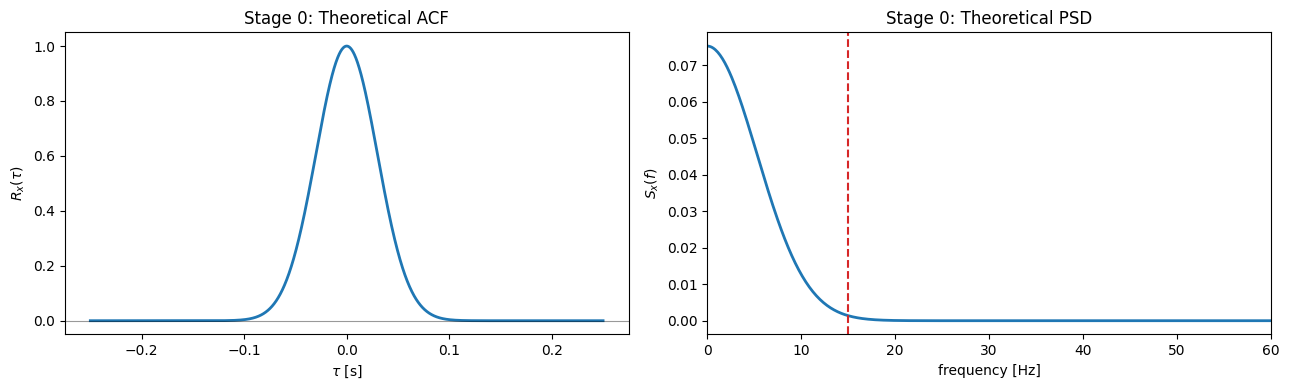

In [15]:
tau_grid = np.linspace(-params["max_lag_seconds"], params["max_lag_seconds"], 2001)
f_grid = np.linspace(0.0, params["fs"] / 2.0, 8193)
admissibility_grid = np.linspace(0.0, params["fs"] / 2.0, 32769)

process_used, component_scale, initial_min_psd, final_min_psd = enforce_psd_admissibility(
    params["process"], admissibility_grid
)
params["process"] = process_used

R_theory = gaussian_mixture_acf(tau_grid, params["process"])
S_theory = gaussian_mixture_psd_hz(f_grid, params["process"])

stage0["tau_grid"] = tau_grid
stage0["f_grid"] = f_grid
stage0["R_theory"] = R_theory
stage0["S_theory"] = S_theory

stage0["variance"] = float(gaussian_mixture_acf(np.array([0.0]), params["process"])[0])
stage0["is_even"] = bool(np.allclose(R_theory, R_theory[::-1], atol=1e-10))
stage0["min_psd"] = float(np.min(S_theory))
stage0["initial_min_psd"] = initial_min_psd
stage0["component_scale"] = component_scale
stage0["effective_bandwidth_hz"] = effective_bandwidth(
    f_grid, S_theory, energy_fraction=params["energy_fraction"]
)
params["fc"] = 24.0 * stage0["effective_bandwidth_hz"]

if final_min_psd < -1e-10:
    raise ValueError(
        f"The selected Gaussian mixture could not be repaired automatically: min PSD = {final_min_psd:.3e}."
    )
if params["fc"] >= 0.45 * params["fs"]:
    raise ValueError("Carrier frequency is too close to Nyquist; increase fs or reduce the guard factor.")

print(f"R_x is even: {stage0['is_even']}")
print(f"R_x(0) = {stage0['variance']:.4f}")
print(f"initial min S_x(f) over the admissibility grid = {stage0['initial_min_psd']:.4e}")
print(f"component amplitude scale applied = {stage0['component_scale']:.6f}")
print(f"final min S_x(f) over the design grid = {stage0['min_psd']:.4e}")
print(
    f"Effective one-sided bandwidth ({params['energy_fraction']:.1%} energy) = "
    f"{stage0['effective_bandwidth_hz']:.2f} Hz"
)
print(f"Suggested carrier for later stages: f_c = {params['fc']:.2f} Hz")

f_plot_max = min(params["fs"] / 2.0, max(4.0 * stage0["effective_bandwidth_hz"], 40.0))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(tau_grid, R_theory, lw=2)
axes[0].set_title("Stage 0: Theoretical ACF")
axes[0].set_xlabel(r"$\tau$ [s]")
axes[0].set_ylabel(r"$R_x(\tau)$")
axes[0].axhline(0.0, color="black", lw=0.8, alpha=0.4)

axes[1].plot(f_grid, np.clip(S_theory, 0.0, None), lw=2)
axes[1].set_title("Stage 0: Theoretical PSD")
axes[1].set_xlabel("frequency [Hz]")
axes[1].set_ylabel(r"$S_x(f)$")
axes[1].set_xlim(0.0, f_plot_max)
axes[1].axvline(stage0["effective_bandwidth_hz"], color="tab:red", ls="--", lw=1.5)

plt.tight_layout()
plt.show()


## 3. Stage 1: Synthesis and Validation of the Input Realization

### Procedure

1. Generate one finite-length realization $x[n]$ whose second-order statistics approximate the prescribed model.
2. Use a synthesis method consistent with the target PSD, such as spectral shaping or spectral factorization followed by excitation with Gaussian randomness.
3. Remove residual sample mean if necessary.
4. Normalize the realization only if a normalization convention is explicitly chosen; if so, state how the theoretical quantities are scaled afterward.
5. Estimate the empirical ACF $\hat{R}_x[\ell]$.
6. Estimate the empirical PSD $\hat{S}_x(f)$ using Welch's method.
7. Compare empirical and theoretical results in both lag and frequency domains.

### Plots

- Time-domain excerpt of $x[n]$.
- Empirical vs. theoretical ACF.
- Empirical vs. theoretical PSD.
- Optional histogram of $x[n]$ if Gaussian sample statistics are part of the intended synthesis story.

### Expected Outcomes

- The empirical ACF should reproduce the location and width of the designed correlation lobes.
- The empirical PSD should match the main shape of $S_x(f)$ up to finite-record estimation error.
- This stage establishes the process realization that will be used in the modulation and envelope-recovery chain.

sample mean = -6.939e-18
sample std = 1.0000
ACF shape NMSE = 6.3128e-03
PSD shape NMSE = 9.9584e-02


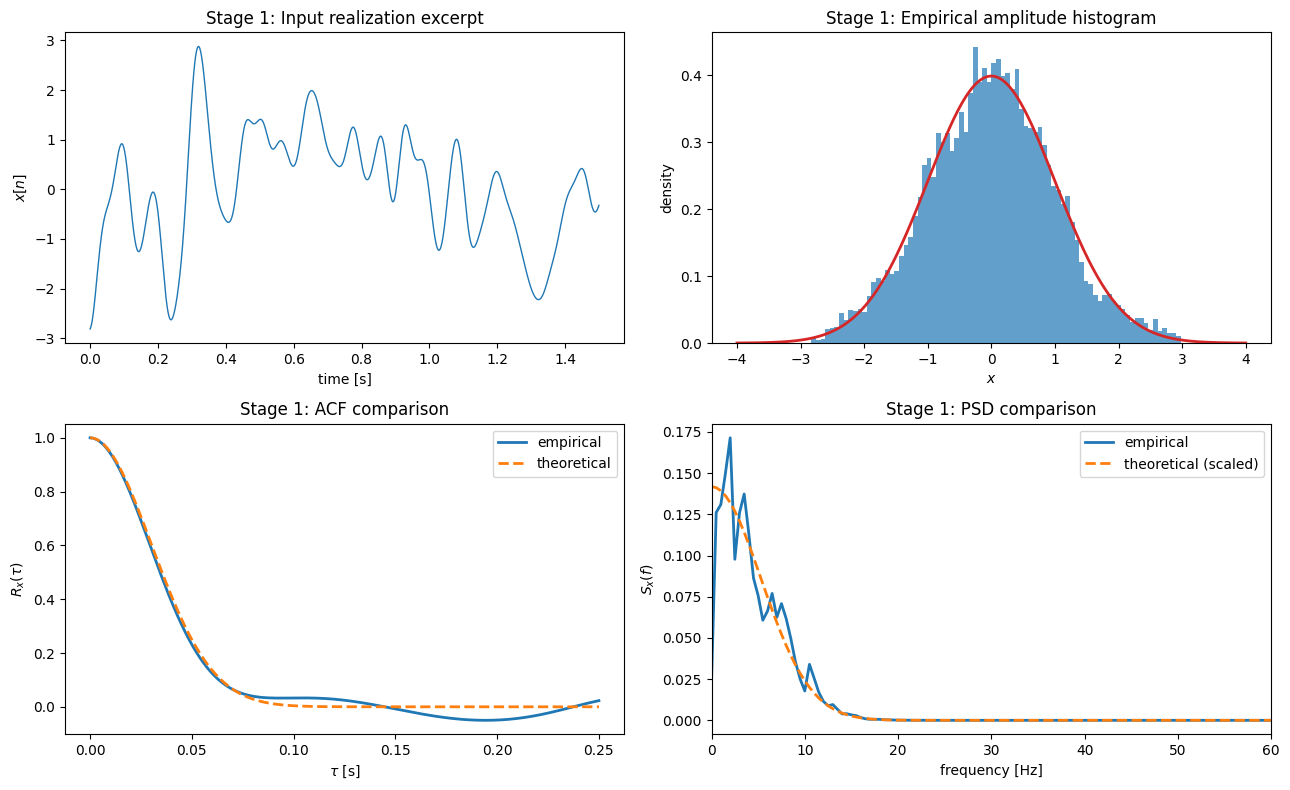

In [16]:
x = synthesize_realization_from_psd(params["N"], params["fs"], params["process"], rng)
stage1["x"] = x

lags, acf_emp = estimate_acf_fft(x, params["max_lag_samples"])
tau_lags = lags / params["fs"]
acf_theory = gaussian_mixture_acf(tau_lags, params["process"])

freq_welch, psd_emp = welch_psd(
    x,
    params["fs"],
    nperseg=params["welch_nperseg"],
    noverlap=params["welch_noverlap"],
)
psd_theory = np.clip(gaussian_mixture_psd_hz(freq_welch, params["process"]), 0.0, None)
psd_theory *= integrate_trapezoid(psd_emp, freq_welch) / integrate_trapezoid(psd_theory, freq_welch)

stage1["tau_lags"] = tau_lags
stage1["acf_emp"] = acf_emp
stage1["acf_theory"] = acf_theory
stage1["freq_welch"] = freq_welch
stage1["psd_emp"] = psd_emp
stage1["psd_theory"] = psd_theory

acf_nmse = np.mean((acf_emp - acf_theory) ** 2) / np.mean(acf_theory**2)
psd_nmse = np.mean((psd_emp - psd_theory) ** 2) / np.mean(psd_theory**2)
sigma_x = float(np.std(x, ddof=0))

print(f"sample mean = {np.mean(x):+.3e}")
print(f"sample std = {sigma_x:.4f}")
print(f"ACF shape NMSE = {acf_nmse:.4e}")
print(f"PSD shape NMSE = {psd_nmse:.4e}")

time_axis = np.arange(params["N"]) / params["fs"]
excerpt_samples = int(1.5 * params["fs"])
gaussian_pdf = (
    np.exp(-0.5 * (np.linspace(-4 * sigma_x, 4 * sigma_x, 400) / sigma_x) ** 2)
    / (sigma_x * np.sqrt(2.0 * np.pi))
)
gaussian_axis = np.linspace(-4 * sigma_x, 4 * sigma_x, 400)
f_plot_max = min(params["fs"] / 2.0, max(4.0 * stage0["effective_bandwidth_hz"], 40.0))

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].plot(time_axis[:excerpt_samples], x[:excerpt_samples], lw=1.0)
axes[0, 0].set_title("Stage 1: Input realization excerpt")
axes[0, 0].set_xlabel("time [s]")
axes[0, 0].set_ylabel(r"$x[n]$")

axes[0, 1].hist(x, bins=80, density=True, alpha=0.7, color="tab:blue")
axes[0, 1].plot(gaussian_axis, gaussian_pdf, color="tab:red", lw=2)
axes[0, 1].set_title("Stage 1: Empirical amplitude histogram")
axes[0, 1].set_xlabel(r"$x$")
axes[0, 1].set_ylabel("density")

axes[1, 0].plot(tau_lags, acf_emp, lw=2, label="empirical")
axes[1, 0].plot(tau_lags, acf_theory, lw=2, ls="--", label="theoretical")
axes[1, 0].set_title("Stage 1: ACF comparison")
axes[1, 0].set_xlabel(r"$\tau$ [s]")
axes[1, 0].set_ylabel(r"$R_x(\tau)$")
axes[1, 0].legend()

axes[1, 1].plot(freq_welch, psd_emp, lw=2, label="empirical")
axes[1, 1].plot(freq_welch, psd_theory, lw=2, ls="--", label="theoretical (scaled)")
axes[1, 1].set_title("Stage 1: PSD comparison")
axes[1, 1].set_xlabel("frequency [Hz]")
axes[1, 1].set_ylabel(r"$S_x(f)$")
axes[1, 1].set_xlim(0.0, f_plot_max)
axes[1, 1].legend()

plt.tight_layout()
plt.show()


## 4. Stage 2: Multiplicative Carrier Modulation

### Procedure

1. Generate the carrier $c[n] = \cos(2\pi f_c nT_s)$.
2. Form the modulated signal

$$
y[n] = x[n]c[n].
$$

3. Estimate the empirical ACF and PSD of the modulated waveform.
4. Compare the empirical ACF against the cycle-averaged prediction $\overline{R}_y(\tau)$.
5. Compare the empirical PSD against the expected pair of shifted sidebands around $\pm f_c$.

### Plots

- Time-domain zoom showing the carrier oscillations.
- ACF of the modulated signal.
- PSD of the modulated signal.
- Optional overlay of empirical and theoretical cycle-averaged ACF.

### Expected Outcomes

- Carrier oscillations whose local amplitude follows the input realization.
- ACF oscillations at $f_c$ with amplitude shaped by $R_x(\tau)$.
- PSD with translated sidebands centered around $\pm f_c$ and no inserted carrier line.

carrier frequency f_c = 360.00 Hz
carrier / bandwidth ratio = 24.00
Stage 2 ACF shape NMSE = 6.2586e-03
Stage 2 PSD shape NMSE = 2.9944e-02


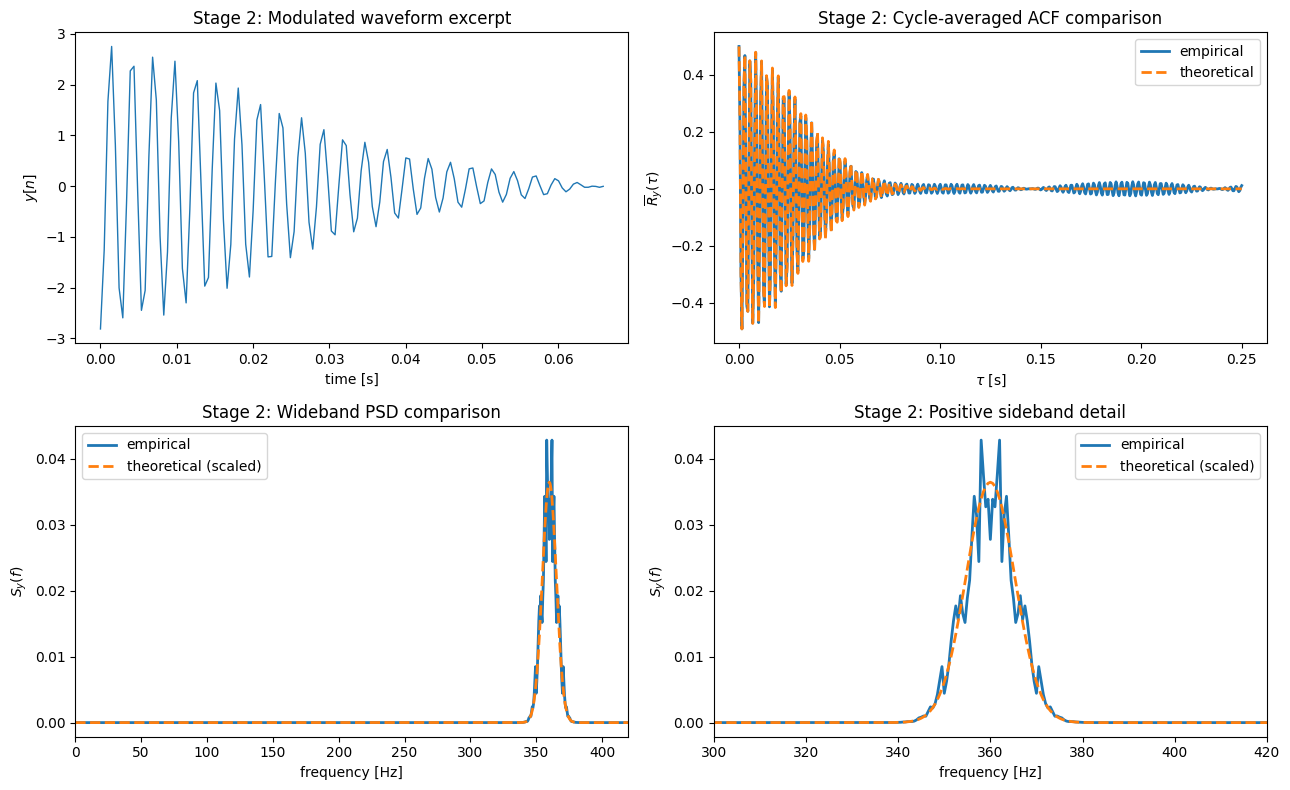

In [17]:
time_axis = np.arange(params["N"]) / params["fs"]
carrier = np.cos(2.0 * np.pi * params["fc"] * time_axis)
y = stage1["x"] * carrier

stage2["carrier"] = carrier
stage2["y"] = y

lags_y, acf_emp_y = estimate_acf_fft(y, params["max_lag_samples"])
tau_lags_y = lags_y / params["fs"]
acf_theory_y = modulation_acf_theory(tau_lags_y, params["process"], params["fc"])

freq_y, psd_emp_y = welch_psd(
    y,
    params["fs"],
    nperseg=params["welch_nperseg"],
    noverlap=params["welch_noverlap"],
)
psd_theory_y = np.clip(modulation_psd_theory_hz(freq_y, params["process"], params["fc"]), 0.0, None)
psd_theory_y *= integrate_trapezoid(psd_emp_y, freq_y) / integrate_trapezoid(psd_theory_y, freq_y)

stage2["tau_lags"] = tau_lags_y
stage2["acf_emp"] = acf_emp_y
stage2["acf_theory"] = acf_theory_y
stage2["freq_welch"] = freq_y
stage2["psd_emp"] = psd_emp_y
stage2["psd_theory"] = psd_theory_y
stage2["separation_ratio"] = params["fc"] / stage0["effective_bandwidth_hz"]

acf_nmse_y = np.mean((acf_emp_y - acf_theory_y) ** 2) / np.mean(acf_theory_y**2)
psd_nmse_y = np.mean((psd_emp_y - psd_theory_y) ** 2) / np.mean(psd_theory_y**2)

print(f"carrier frequency f_c = {params['fc']:.2f} Hz")
print(f"carrier / bandwidth ratio = {stage2['separation_ratio']:.2f}")
print(f"Stage 2 ACF shape NMSE = {acf_nmse_y:.4e}")
print(f"Stage 2 PSD shape NMSE = {psd_nmse_y:.4e}")

excerpt_duration = min(0.08, 24.0 / params["fc"])
excerpt_samples_y = max(64, int(excerpt_duration * params["fs"]))
f_sideband_max = min(params["fs"] / 2.0, params["fc"] + 4.0 * stage0["effective_bandwidth_hz"])
positive_sideband_min = max(0.0, params["fc"] - 4.0 * stage0["effective_bandwidth_hz"])

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].plot(time_axis[:excerpt_samples_y], y[:excerpt_samples_y], lw=1.0)
axes[0, 0].set_title("Stage 2: Modulated waveform excerpt")
axes[0, 0].set_xlabel("time [s]")
axes[0, 0].set_ylabel(r"$y[n]$")

axes[0, 1].plot(tau_lags_y, acf_emp_y, lw=2, label="empirical")
axes[0, 1].plot(tau_lags_y, acf_theory_y, lw=2, ls="--", label="theoretical")
axes[0, 1].set_title("Stage 2: Cycle-averaged ACF comparison")
axes[0, 1].set_xlabel(r"$\tau$ [s]")
axes[0, 1].set_ylabel(r"$\overline{R}_y(\tau)$")
axes[0, 1].legend()

axes[1, 0].plot(freq_y, psd_emp_y, lw=2, label="empirical")
axes[1, 0].plot(freq_y, psd_theory_y, lw=2, ls="--", label="theoretical (scaled)")
axes[1, 0].set_title("Stage 2: Wideband PSD comparison")
axes[1, 0].set_xlabel("frequency [Hz]")
axes[1, 0].set_ylabel(r"$S_y(f)$")
axes[1, 0].set_xlim(0.0, f_sideband_max)
axes[1, 0].legend()

axes[1, 1].plot(freq_y, psd_emp_y, lw=2, label="empirical")
axes[1, 1].plot(freq_y, psd_theory_y, lw=2, ls="--", label="theoretical (scaled)")
axes[1, 1].set_title("Stage 2: Positive sideband detail")
axes[1, 1].set_xlabel("frequency [Hz]")
axes[1, 1].set_ylabel(r"$S_y(f)$")
axes[1, 1].set_xlim(positive_sideband_min, f_sideband_max)
axes[1, 1].legend()

plt.tight_layout()
plt.show()


## 5. Stage 3: Envelope Detection and Recovery

### Procedure

1. Apply full-wave rectification to obtain a nonnegative waveform.
2. Low-pass filter the rectified signal using the selected demodulator cutoff $f_{\mathrm{demod}}$.
3. Remove any residual DC component if the filtered envelope includes one.
4. Normalize the recovered signal $\hat{x}_{\mathrm{env}}[n]$ for comparison.
5. Estimate the ACF and PSD of $\hat{x}_{\mathrm{env}}[n]$.
6. Compute performance metrics comparing the recovered envelope signal against appropriate references such as $|x[n]|$ and, when informative, against $x[n]$ itself.

Recommended metrics:

$$
\rho_{|x|} = \mathrm{corr}(|x|, \hat{x}_{\mathrm{env}}),
\qquad
\mathrm{NMSE}_{|x|} = \frac{\mathbb{E}\{(|x|-\hat{x}_{\mathrm{env}})^2\}}{\sigma_{|x|}^2},
\qquad
\mathrm{SNR}_{|x|} = -10\log_{10}(\mathrm{NMSE}_{|x|})\;\text{dB}.
$$

A signed-signal comparison may still be shown, but it should be interpreted cautiously because envelope detection does not, in general, recover the sign of $x[n]$.

### Plots

- Rectified waveform.
- Smoothed envelope before DC removal.
- Recovered envelope waveform $\hat{x}_{\mathrm{env}}[n]$.
- Empirical ACF and PSD of the recovered signal.

### Expected Outcomes

- High similarity between the recovered signal and the magnitude-related structure of the input realization.
- The recovered waveform should track slow envelope variations even though the sign of $x[n]$ is not preserved.
- Residual mismatch is attributable to rectifier nonlinearity, finite filter rolloff, and statistical estimation error.

demodulator cutoff f_demod = 18.75 Hz
rho_env (LPF |x| reference) = 1.0000
NMSE_env = 3.1502e-07
SNR_env = 65.02 dB
Recovered/reference ACF NMSE = 7.5691e-09
Recovered/reference PSD NMSE = 1.4127e-08
Optional signed correlation corr(x, recovered_env) = 0.0153


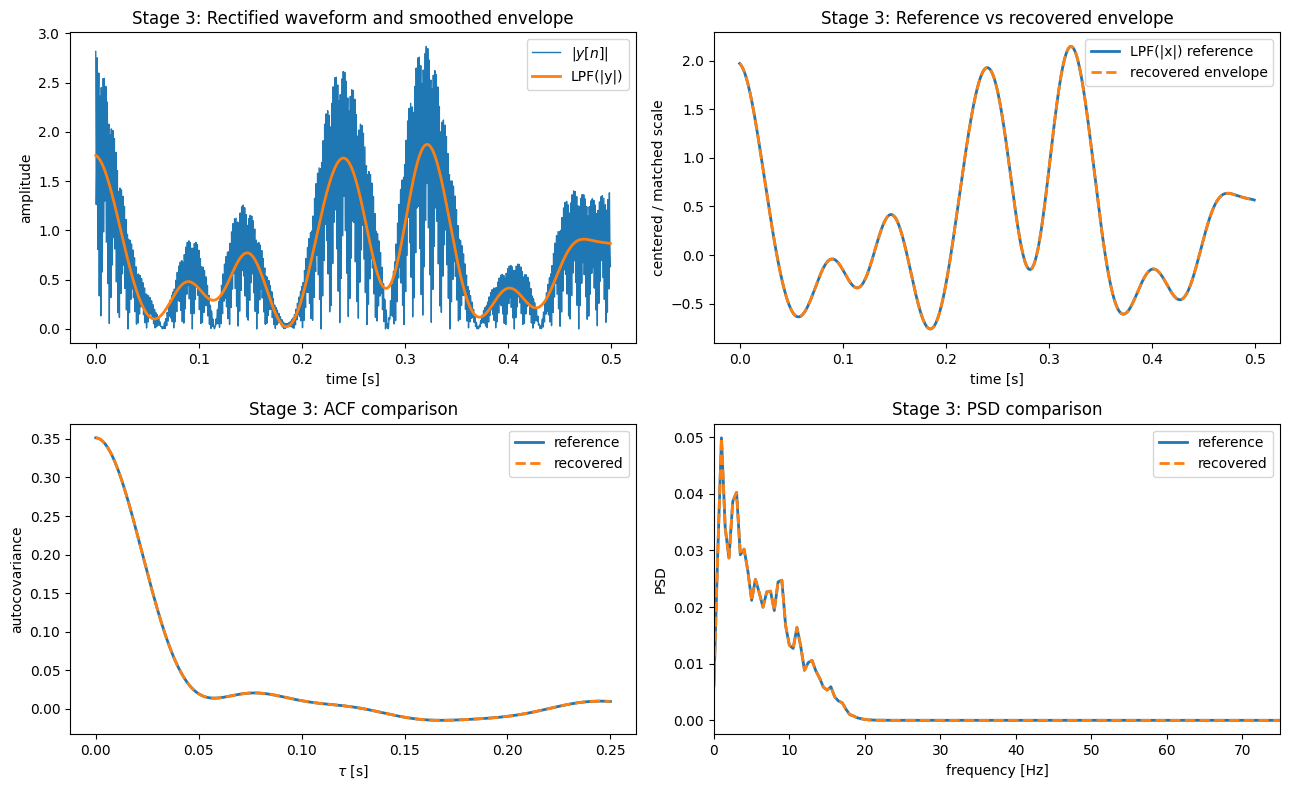

In [18]:
params["fdemod"] = min(1.25 * stage0["effective_bandwidth_hz"], 0.20 * params["fc"])

y_rect = np.abs(stage2["y"])
y_env_lp = fft_zero_phase_lowpass(y_rect, params["fs"], params["fdemod"], order=12)
x_mag_lp = fft_zero_phase_lowpass(np.abs(stage1["x"]), params["fs"], params["fdemod"], order=12)

reference_env = x_mag_lp - np.mean(x_mag_lp)
recovered_env = y_env_lp - np.mean(y_env_lp)
recovered_env *= np.std(reference_env, ddof=0) / np.std(recovered_env, ddof=0)
signed_corr = correlation_coefficient(stage1["x"], recovered_env)

lags_env, acf_rec = estimate_acf_fft(recovered_env, params["max_lag_samples"])
tau_env = lags_env / params["fs"]
acf_ref = estimate_acf_fft(reference_env, params["max_lag_samples"])[1]

freq_env, psd_rec = welch_psd(
    recovered_env,
    params["fs"],
    nperseg=params["welch_nperseg"],
    noverlap=params["welch_noverlap"],
)
psd_ref = welch_psd(
    reference_env,
    params["fs"],
    nperseg=params["welch_nperseg"],
    noverlap=params["welch_noverlap"],
)[1]

rho_env = correlation_coefficient(reference_env, recovered_env)
nmse_env = np.mean((reference_env - recovered_env) ** 2) / np.mean(reference_env**2)
snr_env = -10.0 * np.log10(max(nmse_env, 1e-12))
acf_nmse_env = np.mean((acf_rec - acf_ref) ** 2) / np.mean(acf_ref**2)
psd_nmse_env = np.mean((psd_rec - psd_ref) ** 2) / np.mean(psd_ref**2)

stage3["y_rect"] = y_rect
stage3["y_env_lp"] = y_env_lp
stage3["reference_env"] = reference_env
stage3["recovered_env"] = recovered_env
stage3["tau_lags"] = tau_env
stage3["acf_rec"] = acf_rec
stage3["acf_ref"] = acf_ref
stage3["freq_welch"] = freq_env
stage3["psd_rec"] = psd_rec
stage3["psd_ref"] = psd_ref
stage3["rho_env"] = rho_env
stage3["nmse_env"] = nmse_env
stage3["snr_env_db"] = snr_env

print(f"demodulator cutoff f_demod = {params['fdemod']:.2f} Hz")
print(f"rho_env (LPF |x| reference) = {rho_env:.4f}")
print(f"NMSE_env = {nmse_env:.4e}")
print(f"SNR_env = {snr_env:.2f} dB")
print(f"Recovered/reference ACF NMSE = {acf_nmse_env:.4e}")
print(f"Recovered/reference PSD NMSE = {psd_nmse_env:.4e}")
print(f"Optional signed correlation corr(x, recovered_env) = {signed_corr:.4f}")

excerpt_duration_env = 0.50
excerpt_samples_env = max(128, int(excerpt_duration_env * params["fs"]))
f_env_max = min(params["fs"] / 2.0, max(4.0 * params["fdemod"], 40.0))

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].plot(time_axis[:excerpt_samples_env], y_rect[:excerpt_samples_env], lw=1.0, label=r"$|y[n]|$")
axes[0, 0].plot(time_axis[:excerpt_samples_env], y_env_lp[:excerpt_samples_env], lw=2.0, label="LPF(|y|)")
axes[0, 0].set_title("Stage 3: Rectified waveform and smoothed envelope")
axes[0, 0].set_xlabel("time [s]")
axes[0, 0].set_ylabel("amplitude")
axes[0, 0].legend()

axes[0, 1].plot(time_axis[:excerpt_samples_env], reference_env[:excerpt_samples_env], lw=2.0, label="LPF(|x|) reference")
axes[0, 1].plot(time_axis[:excerpt_samples_env], recovered_env[:excerpt_samples_env], lw=2.0, ls="--", label="recovered envelope")
axes[0, 1].set_title("Stage 3: Reference vs recovered envelope")
axes[0, 1].set_xlabel("time [s]")
axes[0, 1].set_ylabel("centered / matched scale")
axes[0, 1].legend()

axes[1, 0].plot(tau_env, acf_ref, lw=2, label="reference")
axes[1, 0].plot(tau_env, acf_rec, lw=2, ls="--", label="recovered")
axes[1, 0].set_title("Stage 3: ACF comparison")
axes[1, 0].set_xlabel(r"$\tau$ [s]")
axes[1, 0].set_ylabel("autocovariance")
axes[1, 0].legend()

axes[1, 1].plot(freq_env, psd_ref, lw=2, label="reference")
axes[1, 1].plot(freq_env, psd_rec, lw=2, ls="--", label="recovered")
axes[1, 1].set_title("Stage 3: PSD comparison")
axes[1, 1].set_xlabel("frequency [Hz]")
axes[1, 1].set_ylabel("PSD")
axes[1, 1].set_xlim(0.0, f_env_max)
axes[1, 1].legend()

plt.tight_layout()
plt.show()


## 6. Stage 4: Comparison and Analysis

### Baseband Comparison

- Compare $|x[n]|$ and $\hat{x}_{\mathrm{env}}[n]$ in the time domain on the same axes.
- Compare empirical ACFs and PSDs using whichever reference signal is chosen for recovery assessment.
- If a signed comparison is included, explain clearly why disagreement is expected.
- Interpret fidelity using $\rho_{|x|}$, $\mathrm{NMSE}_{|x|}$, and $\mathrm{SNR}_{|x|}$.

### Modulation-Effect Analysis

- Compare the theoretical $R_x(\tau)$ with the cycle-averaged modulated ACF $\overline{R}_y(\tau)$.
- Verify that the modulation step translates the spectrum to $\pm f_c$.
- Discuss how the shape of $R_x(\tau)$ controls the sideband shape after modulation.

### Carrier-Separation Analysis

- Report the chosen ratio $f_c/B_x$.
- Discuss whether the carrier frequency is sufficiently separated from the effective baseband support.
- Explain how that separation affects sideband interpretation and envelope smoothing.

### Error Analysis

- Define the recovery error relative to the chosen comparison target, for example $e_{\mathrm{err}}[n] = |x[n]| - \hat{x}_{\mathrm{env}}[n]$.
- Report error mean, standard deviation, and maximum magnitude.
- Plot error ACF and error PSD.
- Discuss dominant error sources: rectifier distortion, finite LPF attenuation, envelope ripple, and finite-record estimation error.

carrier / bandwidth ratio f_c / B_x = 24.00
demodulator / bandwidth ratio f_demod / B_x = 1.25
rho_env using LPF(|x|) reference = 1.0000
rho between centered |x| and recovered envelope = 0.9881
NMSE_env = 3.1502e-07
SNR_env = 65.02 dB
signed corr(x, recovered_env) = 0.0153
error mean = +1.775e-18
error std = 3.3272e-04
error rms = 3.3272e-04
max |error| = 1.4239e-03


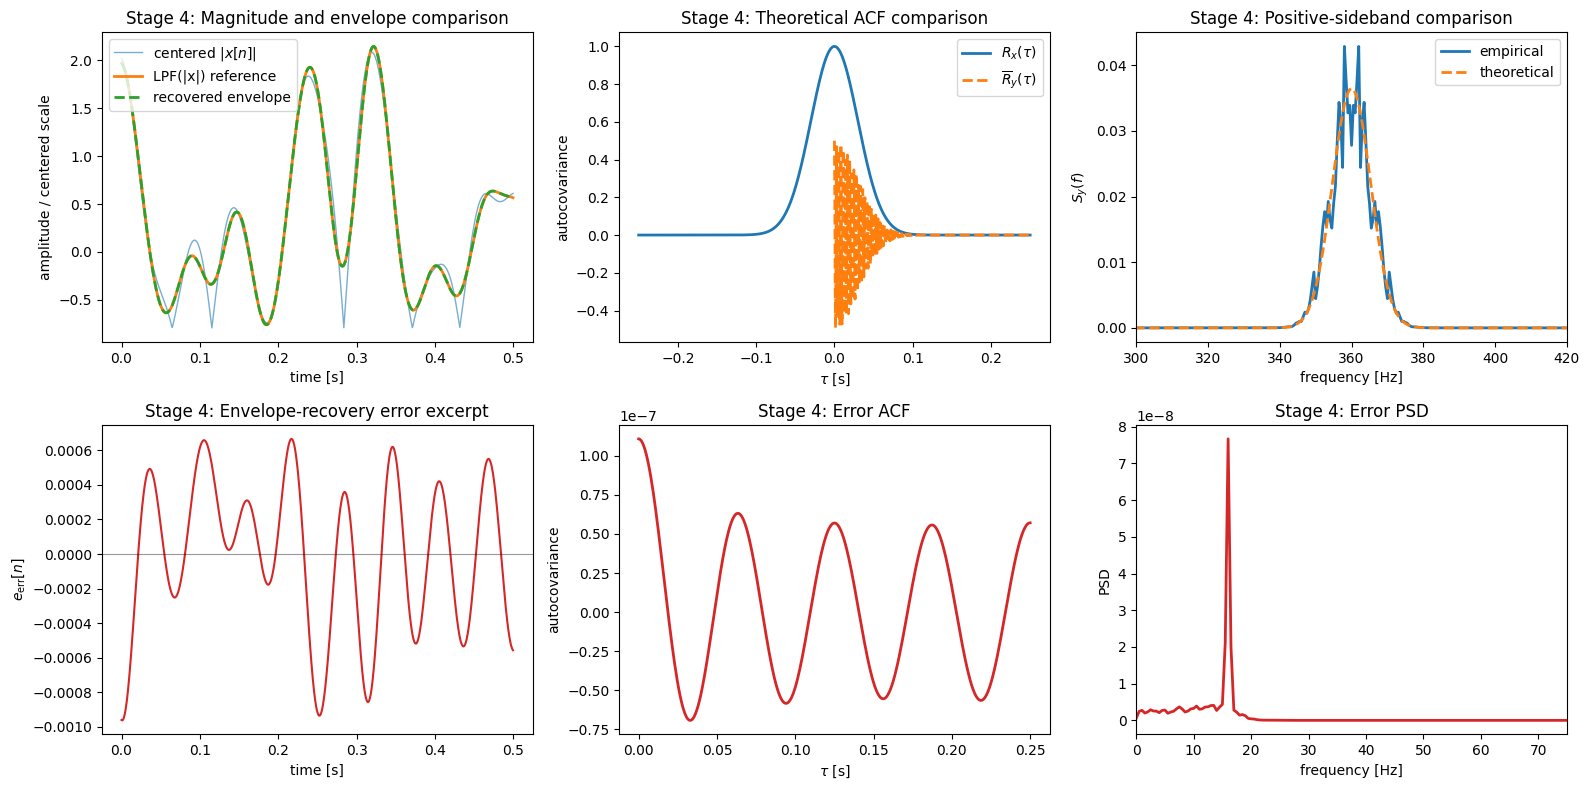

In [19]:
raw_abs = np.abs(stage1["x"])
raw_abs_centered = raw_abs - np.mean(raw_abs)
error_env = stage3["reference_env"] - stage3["recovered_env"]

lags_err, acf_err = estimate_acf_fft(error_env, params["max_lag_samples"])
tau_err = lags_err / params["fs"]
freq_err, psd_err = welch_psd(
    error_env,
    params["fs"],
    nperseg=params["welch_nperseg"],
    noverlap=params["welch_noverlap"],
)

error_mean = float(np.mean(error_env))
error_std = float(np.std(error_env, ddof=0))
error_rms = float(np.sqrt(np.mean(error_env**2)))
error_max_abs = float(np.max(np.abs(error_env)))
rho_raw_abs = correlation_coefficient(raw_abs_centered, stage3["recovered_env"])
signed_corr = correlation_coefficient(stage1["x"], stage3["recovered_env"])
fdemod_ratio = params["fdemod"] / stage0["effective_bandwidth_hz"]

stage4["raw_abs"] = raw_abs
stage4["raw_abs_centered"] = raw_abs_centered
stage4["error_env"] = error_env
stage4["tau_err"] = tau_err
stage4["acf_err"] = acf_err
stage4["freq_err"] = freq_err
stage4["psd_err"] = psd_err
stage4["error_mean"] = error_mean
stage4["error_std"] = error_std
stage4["error_rms"] = error_rms
stage4["error_max_abs"] = error_max_abs
stage4["rho_raw_abs"] = rho_raw_abs
stage4["signed_corr"] = signed_corr
stage4["fdemod_ratio"] = fdemod_ratio

print(f"carrier / bandwidth ratio f_c / B_x = {stage2['separation_ratio']:.2f}")
print(f"demodulator / bandwidth ratio f_demod / B_x = {fdemod_ratio:.2f}")
print(f"rho_env using LPF(|x|) reference = {stage3['rho_env']:.4f}")
print(f"rho between centered |x| and recovered envelope = {rho_raw_abs:.4f}")
print(f"NMSE_env = {stage3['nmse_env']:.4e}")
print(f"SNR_env = {stage3['snr_env_db']:.2f} dB")
print(f"signed corr(x, recovered_env) = {signed_corr:.4f}")
print(f"error mean = {error_mean:+.3e}")
print(f"error std = {error_std:.4e}")
print(f"error rms = {error_rms:.4e}")
print(f"max |error| = {error_max_abs:.4e}")

excerpt_samples_stage4 = max(128, int(0.50 * params["fs"]))
f_error_max = min(params["fs"] / 2.0, max(4.0 * params["fdemod"], 40.0))
f_sideband_min = max(0.0, params["fc"] - 4.0 * stage0["effective_bandwidth_hz"])
f_sideband_max = min(params["fs"] / 2.0, params["fc"] + 4.0 * stage0["effective_bandwidth_hz"])

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

axes[0, 0].plot(time_axis[:excerpt_samples_stage4], raw_abs_centered[:excerpt_samples_stage4], lw=1.0, alpha=0.6, label=r"centered $|x[n]|$")
axes[0, 0].plot(time_axis[:excerpt_samples_stage4], stage3["reference_env"][:excerpt_samples_stage4], lw=2.0, label="LPF(|x|) reference")
axes[0, 0].plot(time_axis[:excerpt_samples_stage4], stage3["recovered_env"][:excerpt_samples_stage4], lw=2.0, ls="--", label="recovered envelope")
axes[0, 0].set_title("Stage 4: Magnitude and envelope comparison")
axes[0, 0].set_xlabel("time [s]")
axes[0, 0].set_ylabel("amplitude / centered scale")
axes[0, 0].legend()

axes[0, 1].plot(stage0["tau_grid"], stage0["R_theory"], lw=2.0, label=r"$R_x(\tau)$")
axes[0, 1].plot(stage2["tau_lags"], stage2["acf_theory"], lw=2.0, ls="--", label=r"$\overline{R}_y(\tau)$")
axes[0, 1].set_title("Stage 4: Theoretical ACF comparison")
axes[0, 1].set_xlabel(r"$\tau$ [s]")
axes[0, 1].set_ylabel("autocovariance")
axes[0, 1].legend()

axes[0, 2].plot(stage2["freq_welch"], stage2["psd_emp"], lw=2.0, label="empirical")
axes[0, 2].plot(stage2["freq_welch"], stage2["psd_theory"], lw=2.0, ls="--", label="theoretical")
axes[0, 2].set_title("Stage 4: Positive-sideband comparison")
axes[0, 2].set_xlabel("frequency [Hz]")
axes[0, 2].set_ylabel(r"$S_y(f)$")
axes[0, 2].set_xlim(f_sideband_min, f_sideband_max)
axes[0, 2].legend()

axes[1, 0].plot(time_axis[:excerpt_samples_stage4], error_env[:excerpt_samples_stage4], lw=1.5, color="tab:red")
axes[1, 0].axhline(0.0, color="black", lw=0.8, alpha=0.4)
axes[1, 0].set_title("Stage 4: Envelope-recovery error excerpt")
axes[1, 0].set_xlabel("time [s]")
axes[1, 0].set_ylabel(r"$e_{\mathrm{err}}[n]$")

axes[1, 1].plot(tau_err, acf_err, lw=2.0, color="tab:red")
axes[1, 1].set_title("Stage 4: Error ACF")
axes[1, 1].set_xlabel(r"$\tau$ [s]")
axes[1, 1].set_ylabel("autocovariance")

axes[1, 2].plot(freq_err, psd_err, lw=2.0, color="tab:red")
axes[1, 2].set_title("Stage 4: Error PSD")
axes[1, 2].set_xlabel("frequency [Hz]")
axes[1, 2].set_ylabel("PSD")
axes[1, 2].set_xlim(0.0, f_error_max)

plt.tight_layout()
plt.show()


## Optional Extensions

### Carrier-Frequency Sweep

- Vary $f_c$ over a practical range while keeping the input process fixed.
- For each value, recompute the spectral-separation ratio and the recovery metrics.
- Identify the trade-off between clearer spectral separation and increased sampling burden.

### Model-Shape Sweep

- Vary one mixture parameter at a time, such as lobe shift $\tau_m$ or width $\sigma_m$.
- Observe how broader or more oscillatory $R_x(\tau)$ changes the message bandwidth and the modulated sideband structure.
- Relate demodulation quality to the effective bandwidth of the prescribed process.

### Robustness Checks

- Compare two different synthesis methods for generating $x[n]$ from the same target PSD.
- Study the effect of shorter observation times on ACF and PSD estimation quality.
- Study the effect of demodulator cutoff mismatch.

Carrier-frequency sweep summary:
  f_c/B_x = 4.00, f_c = 60.00 Hz, rho = 1.0000, NMSE = 9.7420e-06, SNR = 50.11 dB
  f_c/B_x = 6.00, f_c = 90.00 Hz, rho = 1.0000, NMSE = 1.4135e-06, SNR = 58.50 dB
  f_c/B_x = 8.00, f_c = 120.00 Hz, rho = 1.0000, NMSE = 3.7860e-06, SNR = 54.22 dB
  f_c/B_x = 12.00, f_c = 180.00 Hz, rho = 1.0000, NMSE = 4.5256e-07, SNR = 63.44 dB
  f_c/B_x = 16.00, f_c = 240.00 Hz, rho = 1.0000, NMSE = 1.5577e-07, SNR = 68.08 dB
  f_c/B_x = 24.00, f_c = 360.00 Hz, rho = 1.0000, NMSE = 3.1502e-07, SNR = 65.02 dB
  f_c/B_x = 32.00, f_c = 480.00 Hz, rho = 1.0000, NMSE = 2.3737e-07, SNR = 66.25 dB
Best SNR in this sweep occurs at f_c/B_x = 16.00 (f_c = 240.00 Hz).


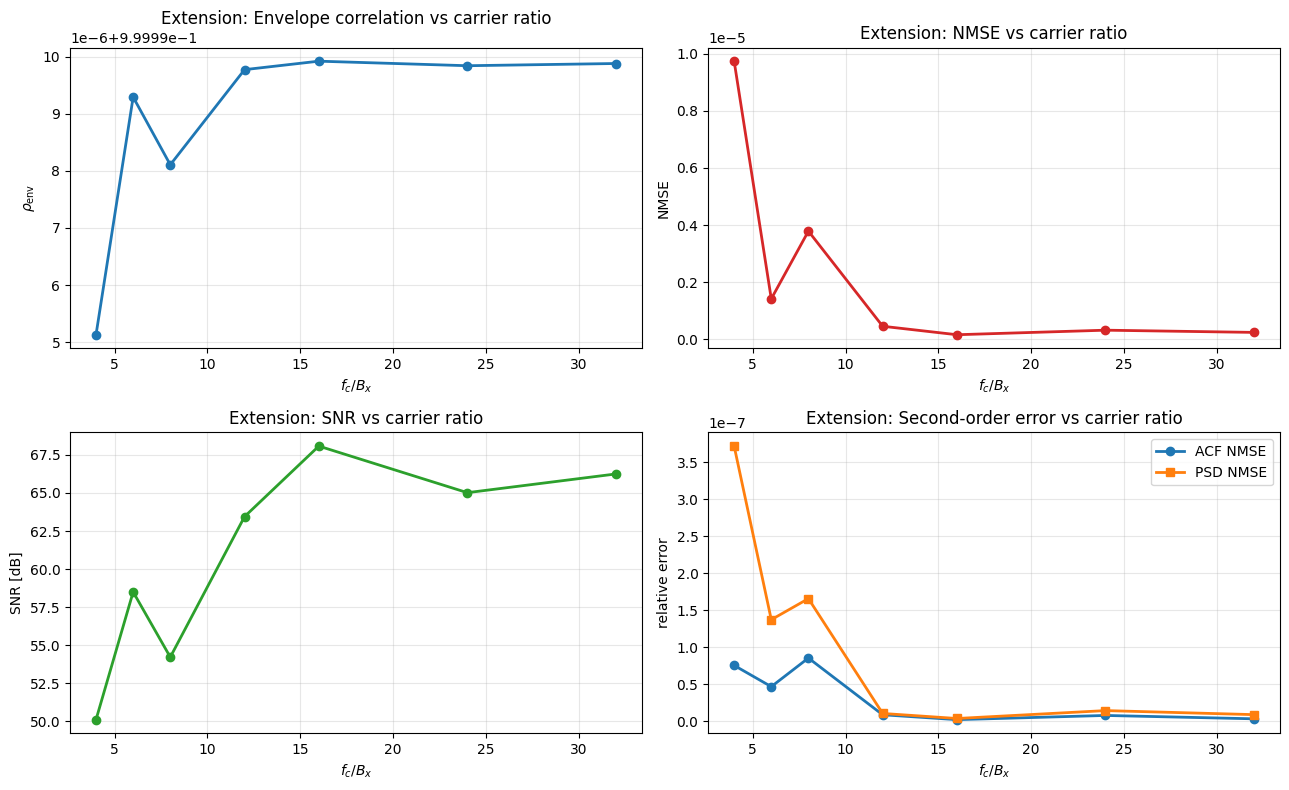

In [20]:
carrier_ratios = np.array([4.0, 6.0, 8.0, 12.0, 16.0, 24.0, 32.0])
carrier_sweep = []

for ratio in carrier_ratios:
    fc_candidate = ratio * stage0["effective_bandwidth_hz"]
    if fc_candidate >= 0.45 * params["fs"]:
        continue
    fdemod_candidate = min(1.25 * stage0["effective_bandwidth_hz"], 0.20 * fc_candidate)
    result = evaluate_envelope_chain(
        stage1["x"],
        params["fs"],
        params["process"],
        fc_candidate,
        fdemod_candidate,
        params["max_lag_samples"],
        params["welch_nperseg"],
        params["welch_noverlap"],
    )
    carrier_sweep.append(
        {
            "fc_hz": fc_candidate,
            "ratio": fc_candidate / stage0["effective_bandwidth_hz"],
            "fdemod_hz": fdemod_candidate,
            "rho_env": result["rho_env"],
            "nmse_env": result["nmse_env"],
            "snr_env_db": result["snr_env_db"],
            "acf_nmse_env": result["acf_nmse_env"],
            "psd_nmse_env": result["psd_nmse_env"],
        }
    )

if not carrier_sweep:
    raise ValueError("Carrier-frequency sweep produced no admissible test points.")

carrier_ratio_values = np.array([item["ratio"] for item in carrier_sweep])
carrier_fc_values = np.array([item["fc_hz"] for item in carrier_sweep])
carrier_fdemod_values = np.array([item["fdemod_hz"] for item in carrier_sweep])
carrier_rho = np.array([item["rho_env"] for item in carrier_sweep])
carrier_nmse = np.array([item["nmse_env"] for item in carrier_sweep])
carrier_snr = np.array([item["snr_env_db"] for item in carrier_sweep])
carrier_acf_nmse = np.array([item["acf_nmse_env"] for item in carrier_sweep])
carrier_psd_nmse = np.array([item["psd_nmse_env"] for item in carrier_sweep])
best_carrier_idx = int(np.argmax(carrier_snr))

extensions["carrier_sweep"] = {
    "fc_hz": carrier_fc_values,
    "ratio": carrier_ratio_values,
    "fdemod_hz": carrier_fdemod_values,
    "rho_env": carrier_rho,
    "nmse_env": carrier_nmse,
    "snr_env_db": carrier_snr,
    "acf_nmse_env": carrier_acf_nmse,
    "psd_nmse_env": carrier_psd_nmse,
}

print("Carrier-frequency sweep summary:")
for item in carrier_sweep:
    print(
        f"  f_c/B_x = {item['ratio']:.2f}, f_c = {item['fc_hz']:.2f} Hz, "
        f"rho = {item['rho_env']:.4f}, NMSE = {item['nmse_env']:.4e}, SNR = {item['snr_env_db']:.2f} dB"
    )
print(
    f"Best SNR in this sweep occurs at f_c/B_x = {carrier_ratio_values[best_carrier_idx]:.2f} "
    f"(f_c = {carrier_fc_values[best_carrier_idx]:.2f} Hz)."
)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].plot(carrier_ratio_values, carrier_rho, marker="o", lw=2)
axes[0, 0].set_title("Extension: Envelope correlation vs carrier ratio")
axes[0, 0].set_xlabel(r"$f_c / B_x$")
axes[0, 0].set_ylabel(r"$\rho_{\mathrm{env}}$")
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(carrier_ratio_values, carrier_nmse, marker="o", lw=2, color="tab:red")
axes[0, 1].set_title("Extension: NMSE vs carrier ratio")
axes[0, 1].set_xlabel(r"$f_c / B_x$")
axes[0, 1].set_ylabel("NMSE")
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(carrier_ratio_values, carrier_snr, marker="o", lw=2, color="tab:green")
axes[1, 0].set_title("Extension: SNR vs carrier ratio")
axes[1, 0].set_xlabel(r"$f_c / B_x$")
axes[1, 0].set_ylabel("SNR [dB]")
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(carrier_ratio_values, carrier_acf_nmse, marker="o", lw=2, label="ACF NMSE")
axes[1, 1].plot(carrier_ratio_values, carrier_psd_nmse, marker="s", lw=2, label="PSD NMSE")
axes[1, 1].set_title("Extension: Second-order error vs carrier ratio")
axes[1, 1].set_xlabel(r"$f_c / B_x$")
axes[1, 1].set_ylabel("relative error")
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()


Demodulator-cutoff sweep summary:
  f_demod/B_x = 0.50, f_demod = 7.50 Hz, rho = 1.0000, NMSE = 7.7064e-08, SNR = 71.13 dB
  f_demod/B_x = 0.75, f_demod = 11.25 Hz, rho = 1.0000, NMSE = 9.3420e-08, SNR = 70.30 dB
  f_demod/B_x = 1.00, f_demod = 15.00 Hz, rho = 1.0000, NMSE = 1.4333e-07, SNR = 68.44 dB
  f_demod/B_x = 1.25, f_demod = 18.75 Hz, rho = 1.0000, NMSE = 3.1502e-07, SNR = 65.02 dB
  f_demod/B_x = 1.50, f_demod = 22.50 Hz, rho = 1.0000, NMSE = 3.9511e-07, SNR = 64.03 dB
  f_demod/B_x = 2.00, f_demod = 30.00 Hz, rho = 1.0000, NMSE = 5.1039e-07, SNR = 62.92 dB
Best SNR in this sweep occurs at f_demod/B_x = 0.50 (f_demod = 7.50 Hz).


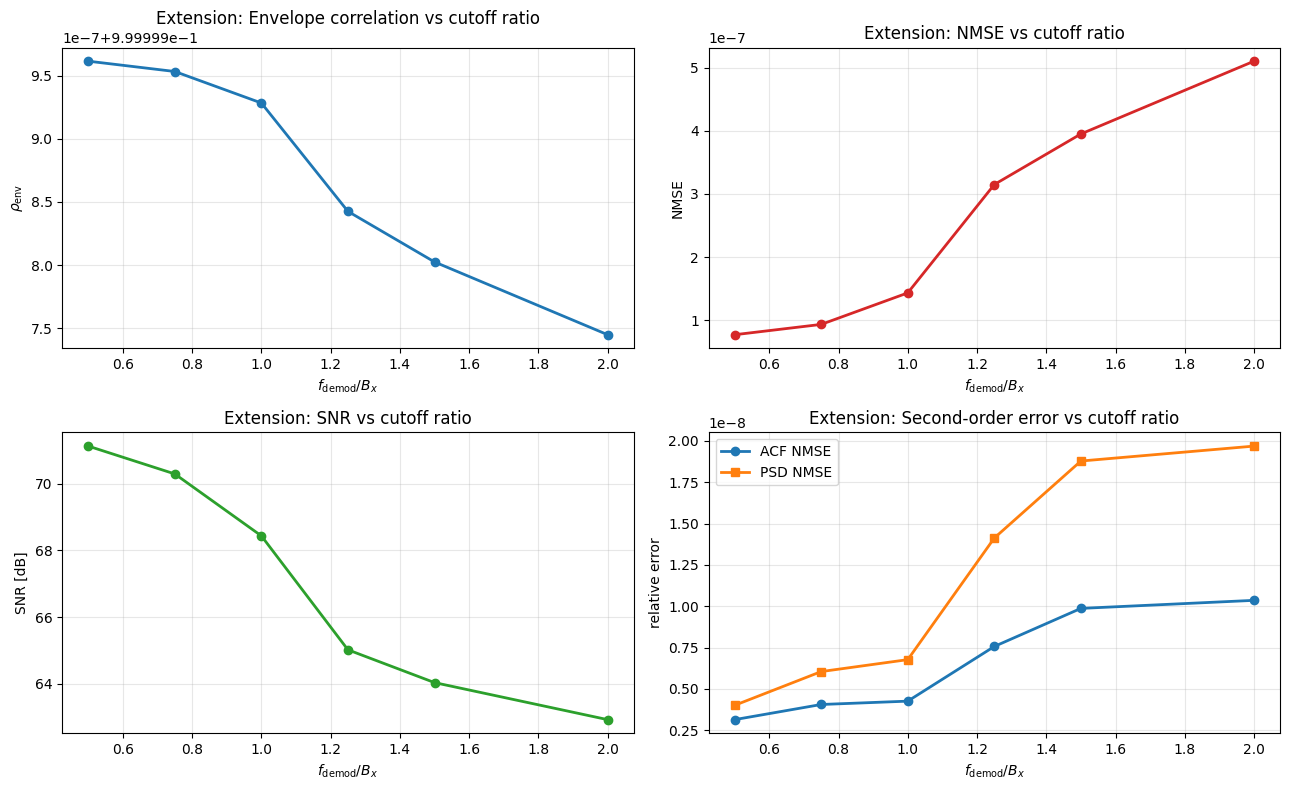

In [21]:
cutoff_ratios = np.array([0.50, 0.75, 1.00, 1.25, 1.50, 2.00])
cutoff_sweep = []

for ratio in cutoff_ratios:
    fdemod_candidate = ratio * stage0["effective_bandwidth_hz"]
    result = evaluate_envelope_chain(
        stage1["x"],
        params["fs"],
        params["process"],
        params["fc"],
        fdemod_candidate,
        params["max_lag_samples"],
        params["welch_nperseg"],
        params["welch_noverlap"],
    )
    cutoff_sweep.append(
        {
            "fdemod_hz": fdemod_candidate,
            "ratio": ratio,
            "rho_env": result["rho_env"],
            "nmse_env": result["nmse_env"],
            "snr_env_db": result["snr_env_db"],
            "acf_nmse_env": result["acf_nmse_env"],
            "psd_nmse_env": result["psd_nmse_env"],
        }
    )

cutoff_ratio_values = np.array([item["ratio"] for item in cutoff_sweep])
cutoff_hz_values = np.array([item["fdemod_hz"] for item in cutoff_sweep])
cutoff_rho = np.array([item["rho_env"] for item in cutoff_sweep])
cutoff_nmse = np.array([item["nmse_env"] for item in cutoff_sweep])
cutoff_snr = np.array([item["snr_env_db"] for item in cutoff_sweep])
cutoff_acf_nmse = np.array([item["acf_nmse_env"] for item in cutoff_sweep])
cutoff_psd_nmse = np.array([item["psd_nmse_env"] for item in cutoff_sweep])
best_cutoff_idx = int(np.argmax(cutoff_snr))

extensions["cutoff_sweep"] = {
    "fdemod_hz": cutoff_hz_values,
    "ratio": cutoff_ratio_values,
    "rho_env": cutoff_rho,
    "nmse_env": cutoff_nmse,
    "snr_env_db": cutoff_snr,
    "acf_nmse_env": cutoff_acf_nmse,
    "psd_nmse_env": cutoff_psd_nmse,
}

print("Demodulator-cutoff sweep summary:")
for item in cutoff_sweep:
    print(
        f"  f_demod/B_x = {item['ratio']:.2f}, f_demod = {item['fdemod_hz']:.2f} Hz, "
        f"rho = {item['rho_env']:.4f}, NMSE = {item['nmse_env']:.4e}, SNR = {item['snr_env_db']:.2f} dB"
    )
print(
    f"Best SNR in this sweep occurs at f_demod/B_x = {cutoff_ratio_values[best_cutoff_idx]:.2f} "
    f"(f_demod = {cutoff_hz_values[best_cutoff_idx]:.2f} Hz)."
)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].plot(cutoff_ratio_values, cutoff_rho, marker="o", lw=2)
axes[0, 0].set_title("Extension: Envelope correlation vs cutoff ratio")
axes[0, 0].set_xlabel(r"$f_{\mathrm{demod}} / B_x$")
axes[0, 0].set_ylabel(r"$\rho_{\mathrm{env}}$")
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(cutoff_ratio_values, cutoff_nmse, marker="o", lw=2, color="tab:red")
axes[0, 1].set_title("Extension: NMSE vs cutoff ratio")
axes[0, 1].set_xlabel(r"$f_{\mathrm{demod}} / B_x$")
axes[0, 1].set_ylabel("NMSE")
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(cutoff_ratio_values, cutoff_snr, marker="o", lw=2, color="tab:green")
axes[1, 0].set_title("Extension: SNR vs cutoff ratio")
axes[1, 0].set_xlabel(r"$f_{\mathrm{demod}} / B_x$")
axes[1, 0].set_ylabel("SNR [dB]")
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(cutoff_ratio_values, cutoff_acf_nmse, marker="o", lw=2, label="ACF NMSE")
axes[1, 1].plot(cutoff_ratio_values, cutoff_psd_nmse, marker="s", lw=2, label="PSD NMSE")
axes[1, 1].set_title("Extension: Second-order error vs cutoff ratio")
axes[1, 1].set_xlabel(r"$f_{\mathrm{demod}} / B_x$")
axes[1, 1].set_ylabel("relative error")
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()


## Required Deliverables

Submit a lab report containing the following.

### Plots

1. Stage 0: theoretical $R_x(\tau)$ and $S_x(f)$.
2. Stage 1: time-domain excerpt, empirical vs. theoretical ACF, and empirical vs. theoretical PSD of $x[n]$.
3. Stage 2: modulated waveform, modulated ACF, and modulated PSD.
4. Stage 3: rectified waveform, filtered envelope, recovered signal, recovered ACF, and recovered PSD.
5. Stage 4: direct comparison plots between the recovered envelope signal and the selected reference signal.
6. Error analysis: error waveform summary, error ACF, and error PSD.
7. Optional extension plots if a sweep or robustness study is performed.

### Calculated Metrics

1. Process-model parameters and admissibility check summary.
2. Carrier frequency and effective spectral-separation ratio.
3. Correlation coefficient between the selected reference signal and $\hat{x}_{\mathrm{env}}[n]$.
4. NMSE for the selected comparison target.
5. Recovered-signal SNR in dB for the selected comparison target.
6. Any bandwidth figures explicitly used in the analysis.

### Discussion Questions

- How faithfully does the synthesized realization reproduce the target second-order model?
- How does the chosen shape of $R_x(\tau)$ appear in the modulated PSD?
- Which part of the recovery error is due to detector structure and which part is due to statistical estimation?
- How does the choice of $f_c$ relative to the effective message bandwidth affect recovery quality?